In [482]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from pathlib import Path

In [483]:
data_path=Path.cwd().parent/'data'/'raw'/'loan_approval_dataset.csv'
df=pd.read_csv(data_path)
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [484]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [485]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [486]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [487]:
work_df=df.copy()

In [488]:
work_df[' no_of_dependents'].value_counts()

 no_of_dependents
4    752
3    727
0    712
2    708
1    697
5    673
Name: count, dtype: int64

In [489]:
work_df.rename(columns={' no_of_dependents':'no_of_dependents'},inplace=True)
work_df.rename(columns={' education':'education'},inplace=True)
work_df.rename(columns={' self_employed':'self_employed'},inplace=True)
work_df.rename(columns={' cibil_score':'cibil_score'},inplace=True)
work_df.rename(columns={' residential_assets_value':'residential_assets_value'},inplace=True)
work_df.rename(columns={' commercial_assets_value':'commercial_assets_value'},inplace=True)
work_df.rename(columns={' luxury_assets_value':'luxury_assets_value'},inplace=True)
work_df.rename(columns={' bank_asset_value':'bank_asset_value'},inplace=True)
work_df.rename(columns={' loan_status':'loan_status'},inplace=True)
work_df.rename(columns={' loan_amount':'loan_amount'},inplace=True)
work_df.rename(columns={' income_annum':'income_annum'},inplace=True)
work_df.rename(columns={' loan_term':'loan_term'},inplace=True)
work_df.rename(columns={' loan_id':'loan_id'},inplace=True)




In [490]:
work_df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [491]:
work_df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [492]:
work_df.no_of_dependents.value_counts()

no_of_dependents
4    752
3    727
0    712
2    708
1    697
5    673
Name: count, dtype: int64

In [493]:
work_df.education.value_counts()

education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

In [494]:
work_df.self_employed.value_counts()

self_employed
Yes    2150
No     2119
Name: count, dtype: int64

In [495]:
work_df.loan_status.value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [496]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [497]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [498]:
df.duplicated().sum()

np.int64(0)

In [499]:
work_df.income_annum.value_counts()

income_annum
7000000    62
4100000    59
7600000    57
4700000    56
6900000    55
           ..
3600000    33
3400000    33
9300000    33
8500000    32
6700000    30
Name: count, Length: 98, dtype: int64

In [500]:
mean=work_df['loan_amount'].mean()
median=work_df['loan_amount'].median()

<Axes: ylabel='cibil_score'>

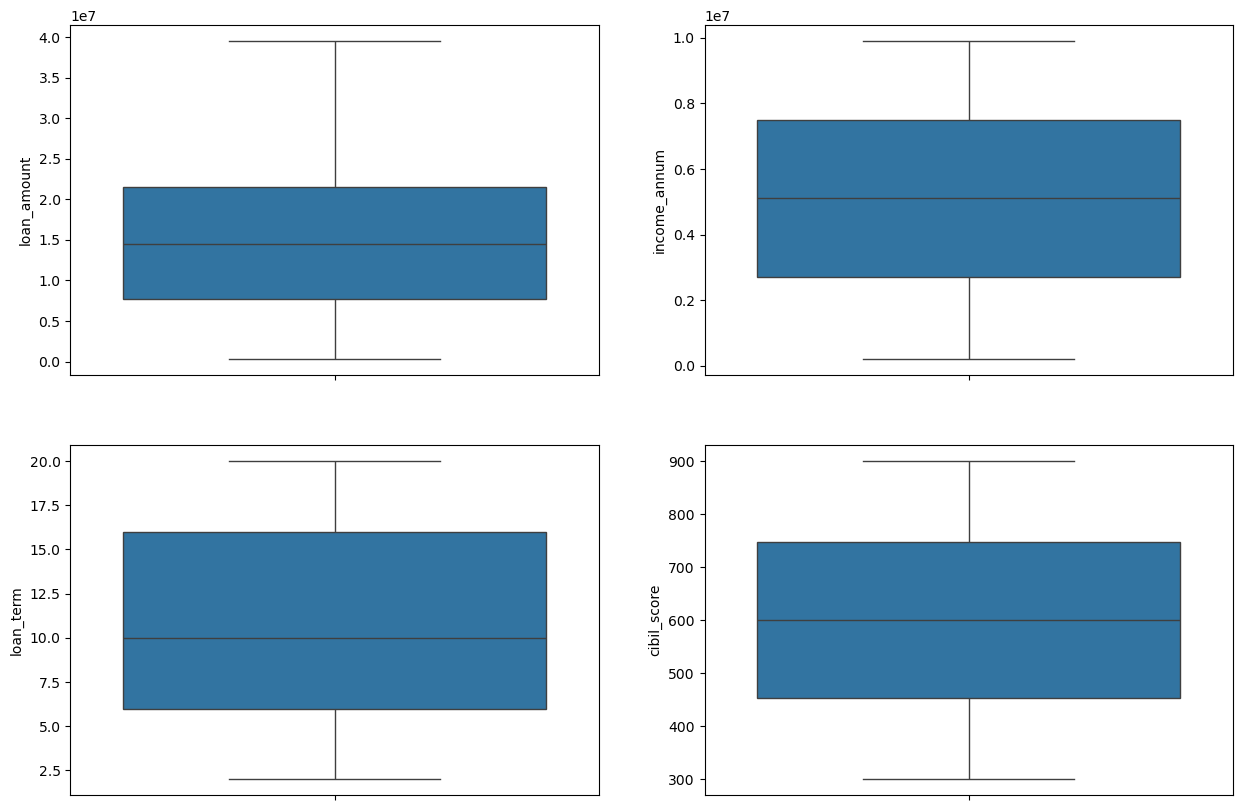

In [501]:
fig,ax=plt.subplots(2,2,figsize=(15,10))
sns.boxplot(work_df['loan_amount'],ax=ax[0,0])
sns.boxplot(work_df['income_annum'],ax=ax[0,1])
sns.boxplot(work_df['loan_term'],ax=ax[1,0])
sns.boxplot(work_df['cibil_score'],ax=ax[1,1])

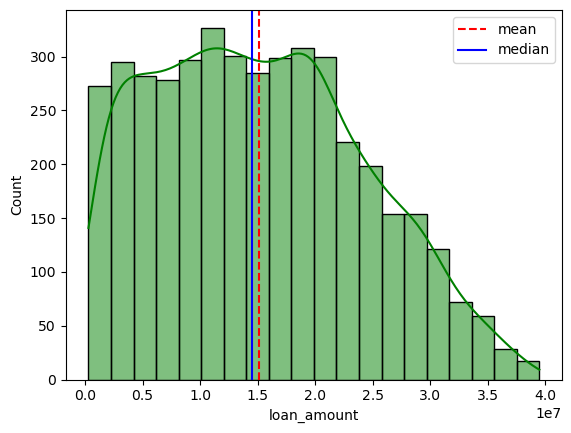

In [502]:
sns.histplot(work_df['loan_amount'],kde=True,color='green',bins=20)
plt.axvline([mean],color='red',linestyle='dashed',label='mean')
plt.axvline([median],color='blue',label='median')
plt.legend()


In [503]:
mean=work_df['income_annum'].mean()
median=work_df['income_annum'].median()

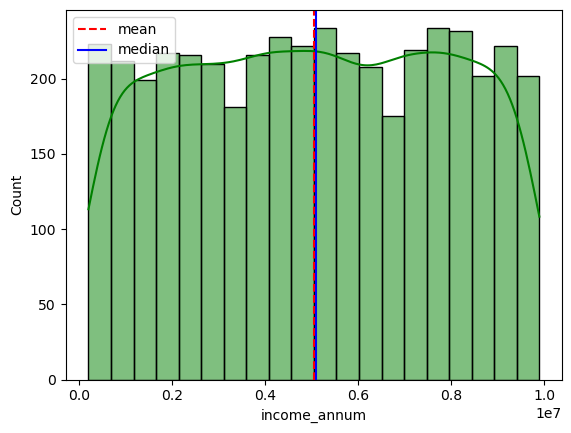

In [504]:
sns.histplot(work_df['income_annum'],kde=True,color='green',bins=20)
plt.axvline([mean],color='red',linestyle='dashed',label='mean')
plt.axvline([median],color='blue',label='median')
plt.legend()

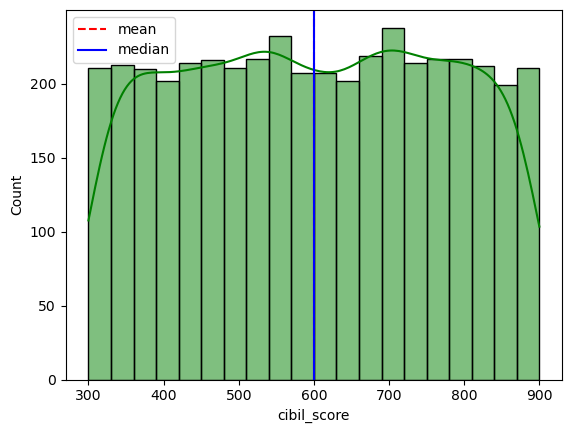

In [505]:
sns.histplot(work_df['cibil_score'],kde=True,color='green',bins=20)
mean=work_df['cibil_score'].mean()
median=work_df['cibil_score'].median()
plt.axvline([mean],color='red',linestyle='dashed',label='mean')
plt.axvline([median],color='blue',label='median')
plt.legend()

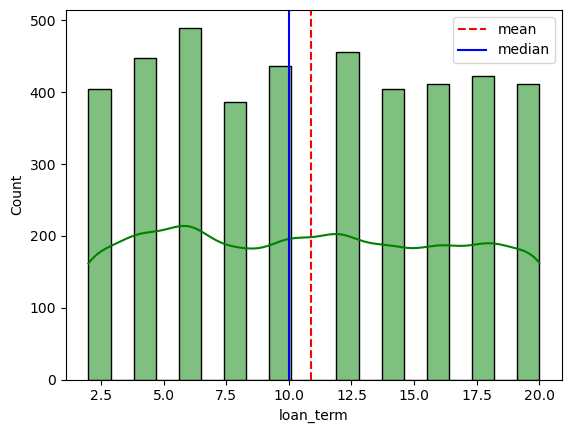

In [506]:
sns.histplot(work_df['loan_term'],kde=True,color='green',bins=20)
mean=work_df['loan_term'].mean()
median=work_df['loan_term'].median()
plt.axvline([mean],color='red',linestyle='dashed',label='mean')
plt.axvline([median],color='blue',label='median')
plt.legend()

In [507]:
work_df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


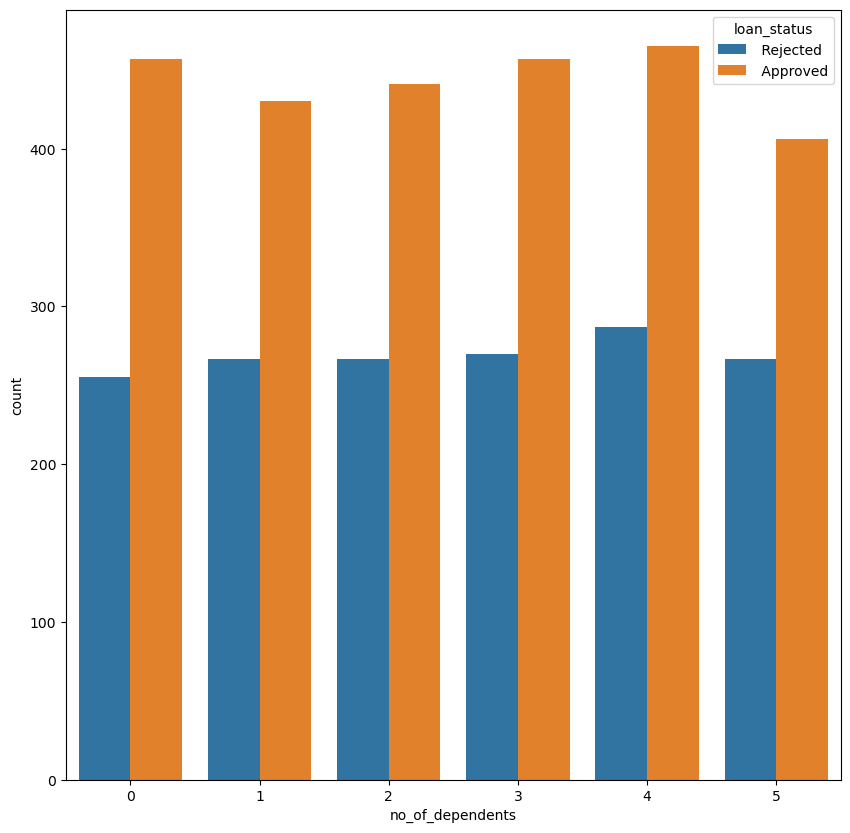

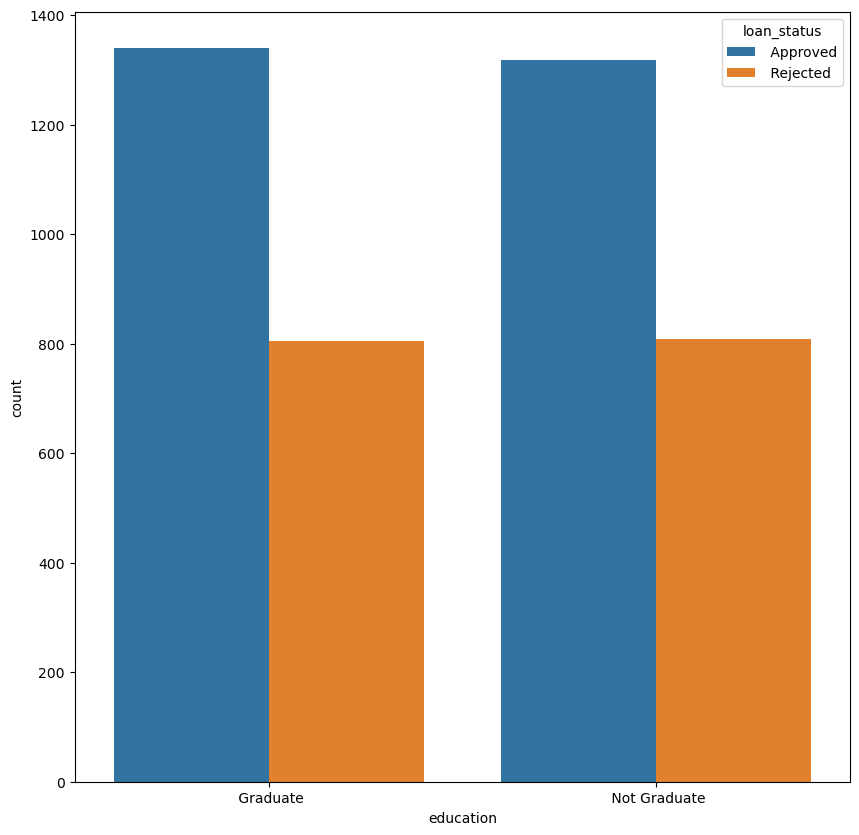

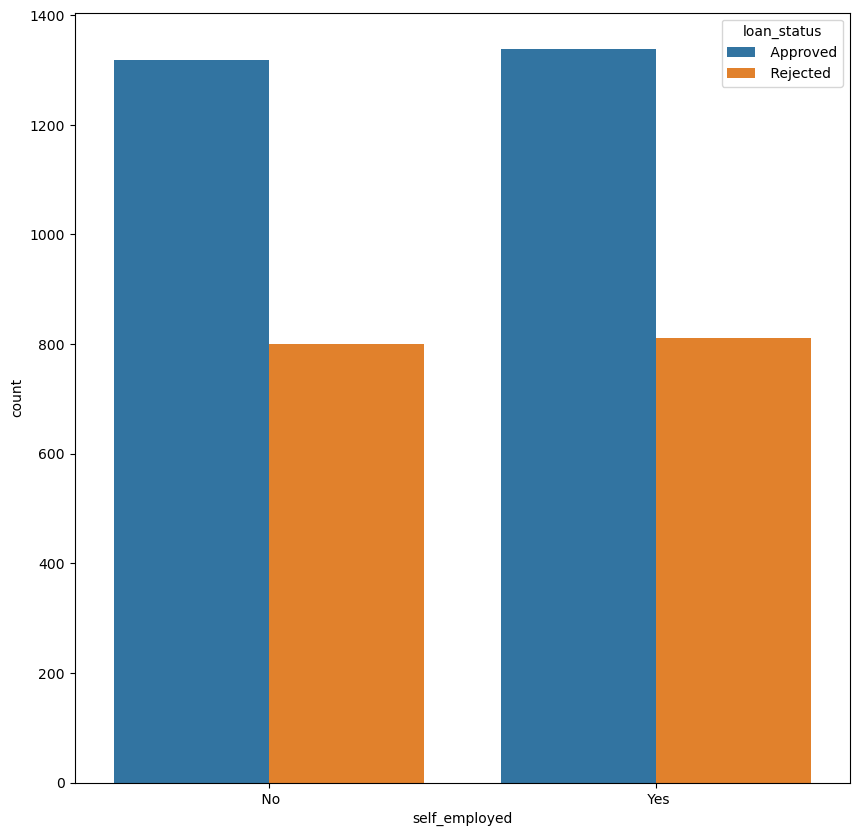

In [508]:
cat_col=['no_of_dependents','education','self_employed']
for i in cat_col:
    plt.figure(figsize=(10,10))
    sns.countplot(x=work_df[i],hue=work_df['loan_status'])
    

([<matplotlib.patches.Wedge at 0x1dfe89d1a90>,
 [Text(-0.41186725769241783, 1.0199830204669722, 'Approved'),
  Text(0.4118671036792618, -1.0199830826571863, 'Rejected')],
 [Text(-0.22465486783222788, 0.5563543748001666, '62.2%'),
  Text(0.22465478382505188, -0.5563544087221015, '37.8%')])

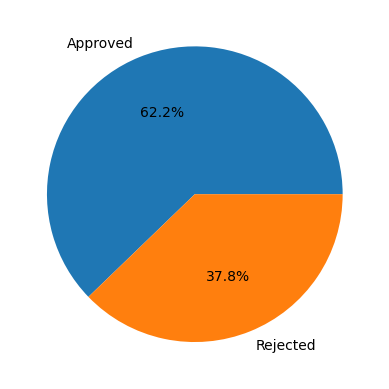

In [509]:
plt.pie(work_df['loan_status'].value_counts(),labels=['Approved','Rejected'],autopct='%1.1f%%')

In [510]:
work_df['debt_to_income'] = work_df['loan_amount'] / work_df['income_annum']

In [511]:
work_df['total_assets'] = (
    work_df['residential_assets_value'] +
    work_df['commercial_assets_value'] +
    work_df['luxury_assets_value'] +
    work_df['bank_asset_value']
)

In [512]:
work_df['emi_estimated'] = work_df['loan_amount'] / work_df['loan_term']

In [513]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [514]:
from sklearn.preprocessing import LabelEncoder
obj_columns=work_df.select_dtypes(include='object').columns.to_list()
encoder_col={}
for i in obj_columns:
    encoder=LabelEncoder()
    work_df[i]=encoder.fit_transform(work_df[i])
    encoder_col[i]=encoder

In [515]:
encoder_col

{'education': LabelEncoder(),
 'self_employed': LabelEncoder(),
 'loan_status': LabelEncoder()}

In [516]:
work_df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,debt_to_income,total_assets,emi_estimated
0,1,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0,3.114583,50700000,2.491667e+06
1,2,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1,2.975610,17000000,1.525000e+06
2,3,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1,3.263736,57700000,1.485000e+06
3,4,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1,3.743902,52700000,3.837500e+06
4,5,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1,2.469388,55000000,1.210000e+06


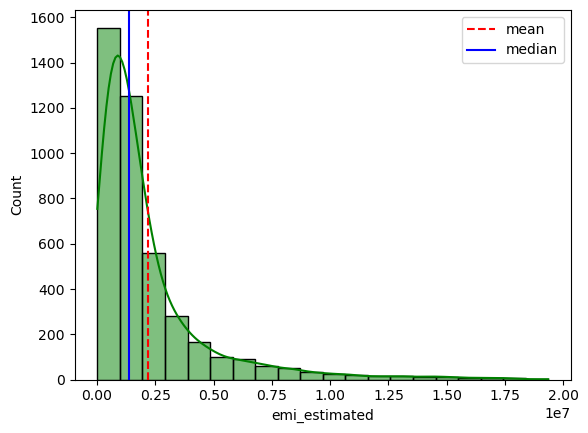

In [517]:
sns.histplot(work_df['emi_estimated'],kde=True,color='green',bins=20)
mean=work_df['emi_estimated'].mean()
median=work_df['emi_estimated'].median()
plt.axvline([mean],color='red',linestyle='dashed',label='mean')
plt.axvline([median],color='blue',label='median')
plt.legend()

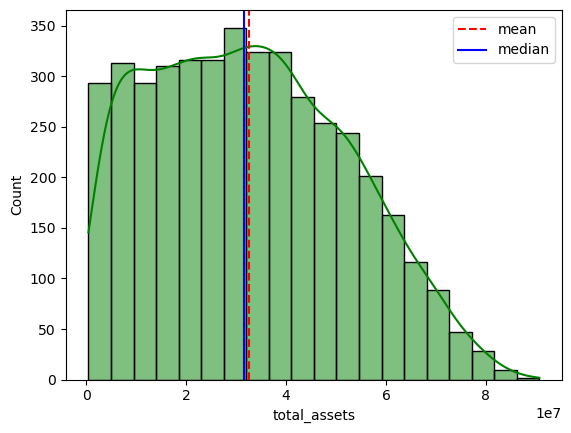

In [518]:
sns.histplot(work_df['total_assets'],kde=True,color='green',bins=20)
mean=work_df['total_assets'].mean()
median=work_df['total_assets'].median()
plt.axvline([mean],color='red',linestyle='dashed',label='mean')
plt.axvline([median],color='blue',label='median')
plt.legend()

<Axes: >

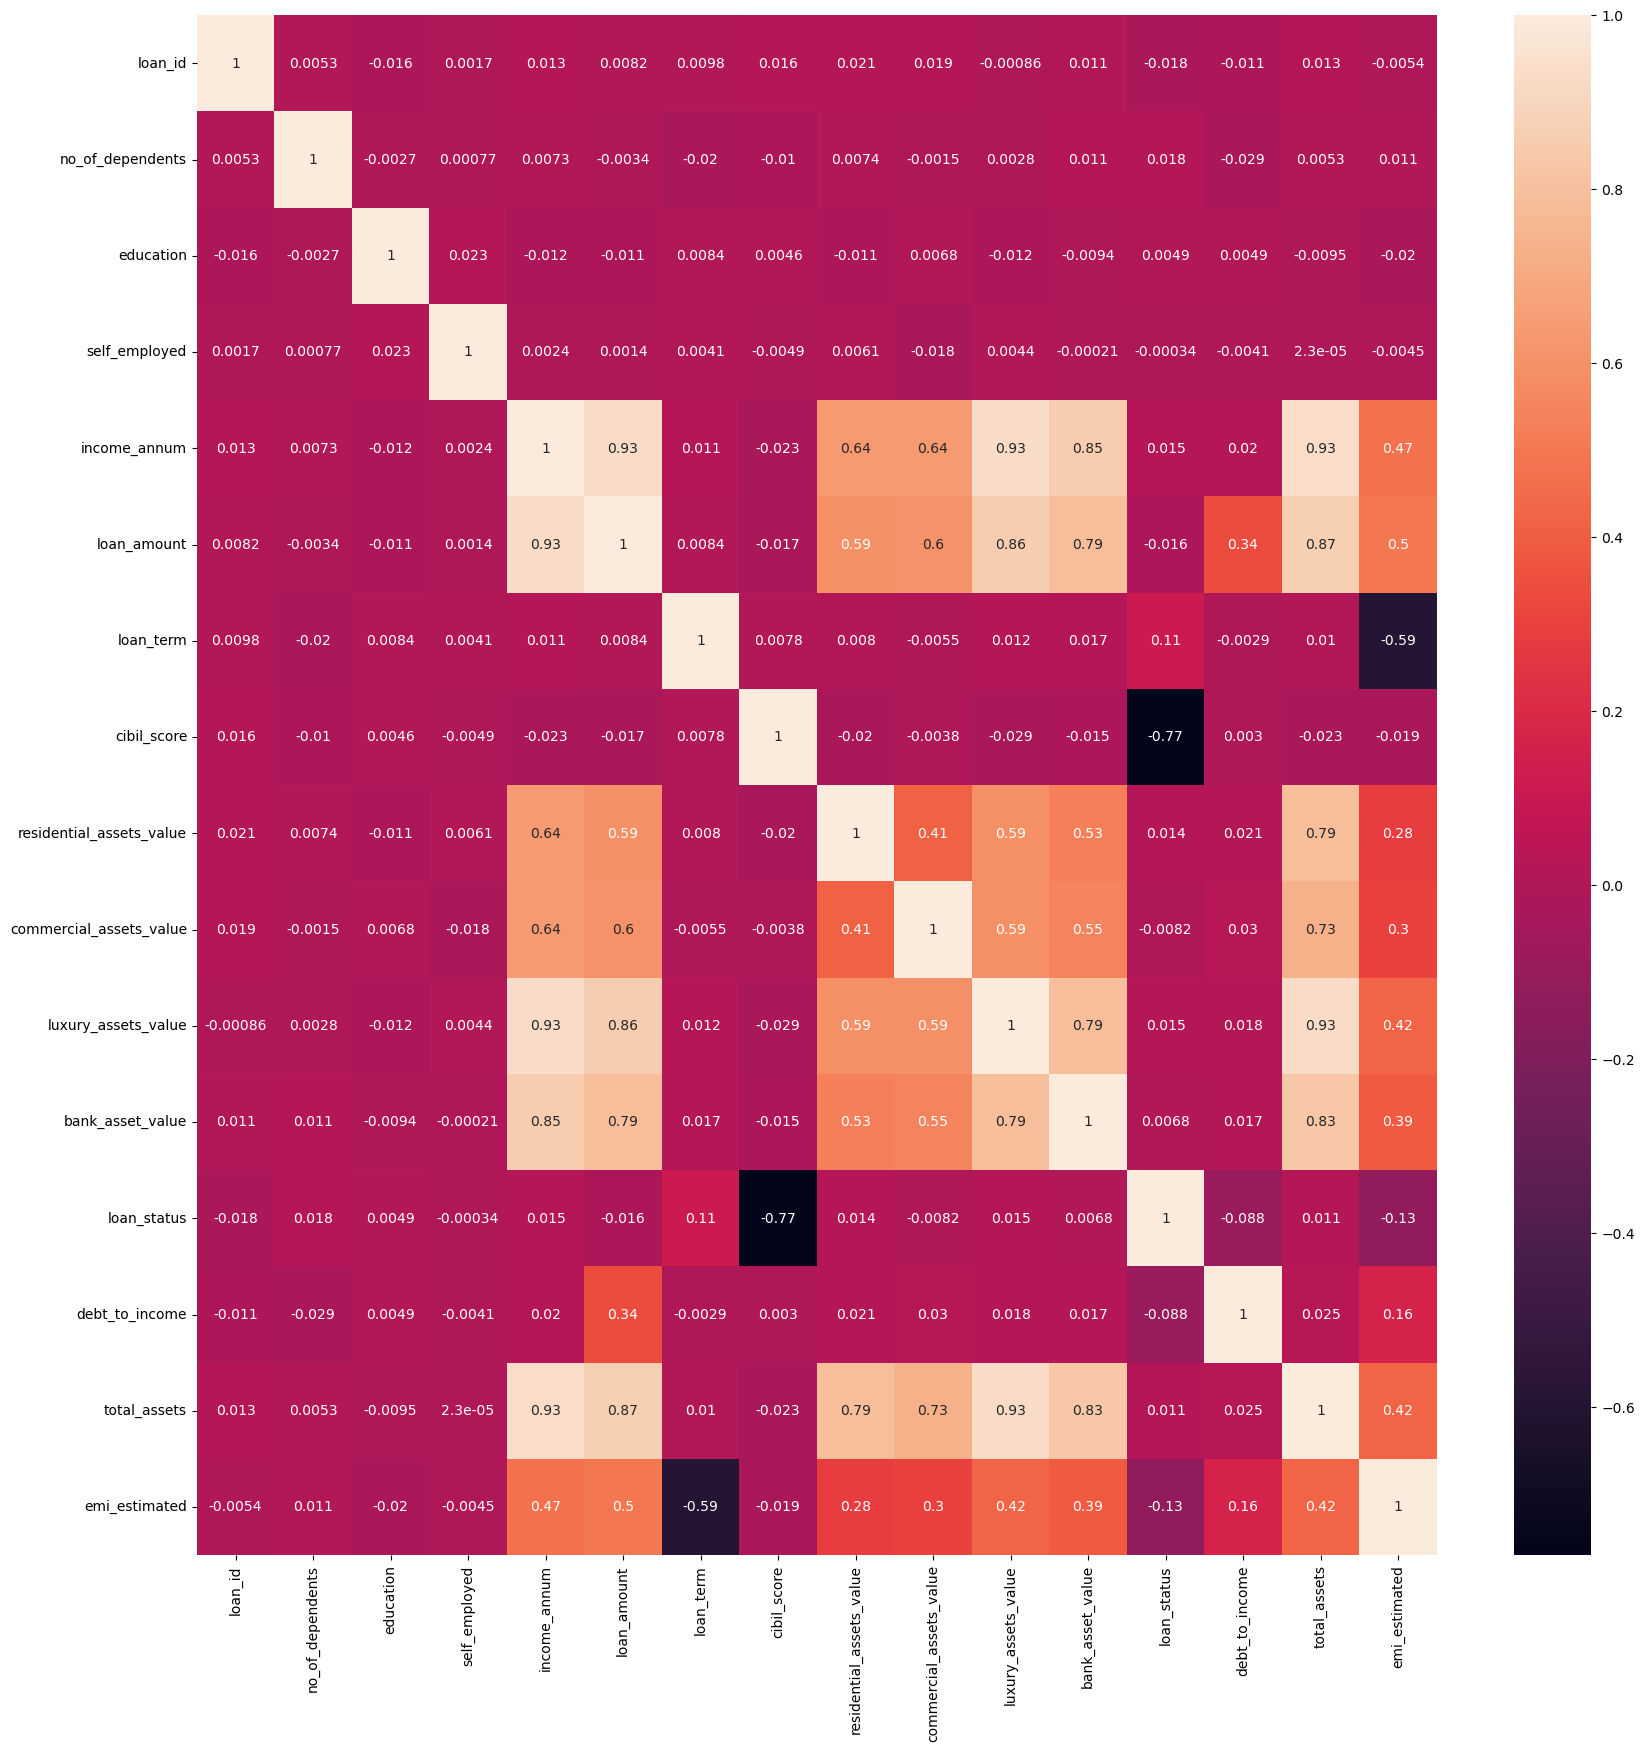

In [519]:
plt.figure(figsize=(20,20))
sns.heatmap(work_df.corr(),annot=True)

In [520]:
corr_rank = work_df.corr()['loan_status'].abs().sort_values(ascending=False)
print(corr_rank)

loan_status                 1.000000
cibil_score                 0.770518
emi_estimated               0.125542
loan_term                   0.113036
debt_to_income              0.087726
no_of_dependents            0.018114
loan_id                     0.017685
loan_amount                 0.016150
luxury_assets_value         0.015465
income_annum                0.015189
residential_assets_value    0.014367
total_assets                0.011281
commercial_assets_value     0.008246
bank_asset_value            0.006778
education                   0.004918
self_employed               0.000345
Name: loan_status, dtype: float64


In [521]:
X=work_df.drop('loan_status',axis=1)
y=work_df['loan_status']


In [522]:
y.value_counts()

loan_status
0    2656
1    1613
Name: count, dtype: int64

In [523]:
print(X.shape,y.shape)

(4269, 15) (4269,)


In [524]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

In [525]:
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(2988, 15) (1281, 15) (2988,) (1281,)


In [526]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score,roc_auc_score,recall_score,precision_score
scores = {
    'model': [],
    'train_accuracy': [],
    'test_accuracy': [],
    'precision': [],
    'recall': [],
    'f1_score': []
}
def evaluate_model(model, model_name=""):
    
    y_train_pred = model.predict(x_train)
    
    y_test_pred = model.predict(x_test)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    
    print(f"\n===== {model_name} =====")
    print("Train Accuracy:", train_acc)
    print("Test Accuracy:", test_acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    
    scores['model'].append(model_name)
    scores['train_accuracy'].append(train_acc)
    scores['test_accuracy'].append(test_acc)
    scores['precision'].append(precision)
    scores['recall'].append(recall)
    scores['f1_score'].append(f1)

In [527]:
from sklearn.linear_model import LogisticRegression
log_l2 = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=500)
log_l2.fit(x_train, y_train)
print("Logistic Regression (L2)")
evaluate_model(log_l2,"Logistic Regression (L2)")


Logistic Regression (L2)

===== Logistic Regression (L2) =====
Train Accuracy: 0.8142570281124498
Test Accuracy: 0.8188914910226386
Precision: 0.815
Recall: 0.6735537190082644
F1 Score: 0.7375565610859729


In [528]:
log_l1 = LogisticRegression(penalty='l1', solver='liblinear', max_iter=500)
log_l1.fit(x_train, y_train)

print("Logistic Regression (L1)")
evaluate_model(log_l1,"Logistic Regression (L1)")

Logistic Regression (L1)

===== Logistic Regression (L1) =====
Train Accuracy: 0.9226907630522089
Test Accuracy: 0.9359875097580016
Precision: 0.9331896551724138
Recall: 0.8946280991735537
F1 Score: 0.9135021097046413


In [529]:
from sklearn.tree import DecisionTreeClassifier
dt_gini = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)
dt_gini.fit(x_train, y_train)
evaluate_model(dt_gini,"Decision Tree (Gini)")


===== Decision Tree (Gini) =====
Train Accuracy: 1.0
Test Accuracy: 0.9937548790007806
Precision: 0.9917355371900827
Recall: 0.9917355371900827
F1 Score: 0.9917355371900827


In [530]:
dt_entropy = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)
dt_entropy.fit(x_train, y_train)
evaluate_model(dt_entropy,"Decision Tree (Entropy)")


===== Decision Tree (Entropy) =====
Train Accuracy: 1.0
Test Accuracy: 0.990632318501171
Precision: 0.98559670781893
Recall: 0.9896694214876033
F1 Score: 0.9876288659793815


In [531]:
dt_tuned_manual = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_tuned_manual.fit(x_train, y_train)

evaluate_model(dt_tuned_manual,"Decision Tree (Manual Tuned)")


===== Decision Tree (Manual Tuned) =====
Train Accuracy: 0.9963186077643909
Test Accuracy: 0.9960967993754879
Precision: 1.0
Recall: 0.9896694214876033
F1 Score: 0.9948078920041536


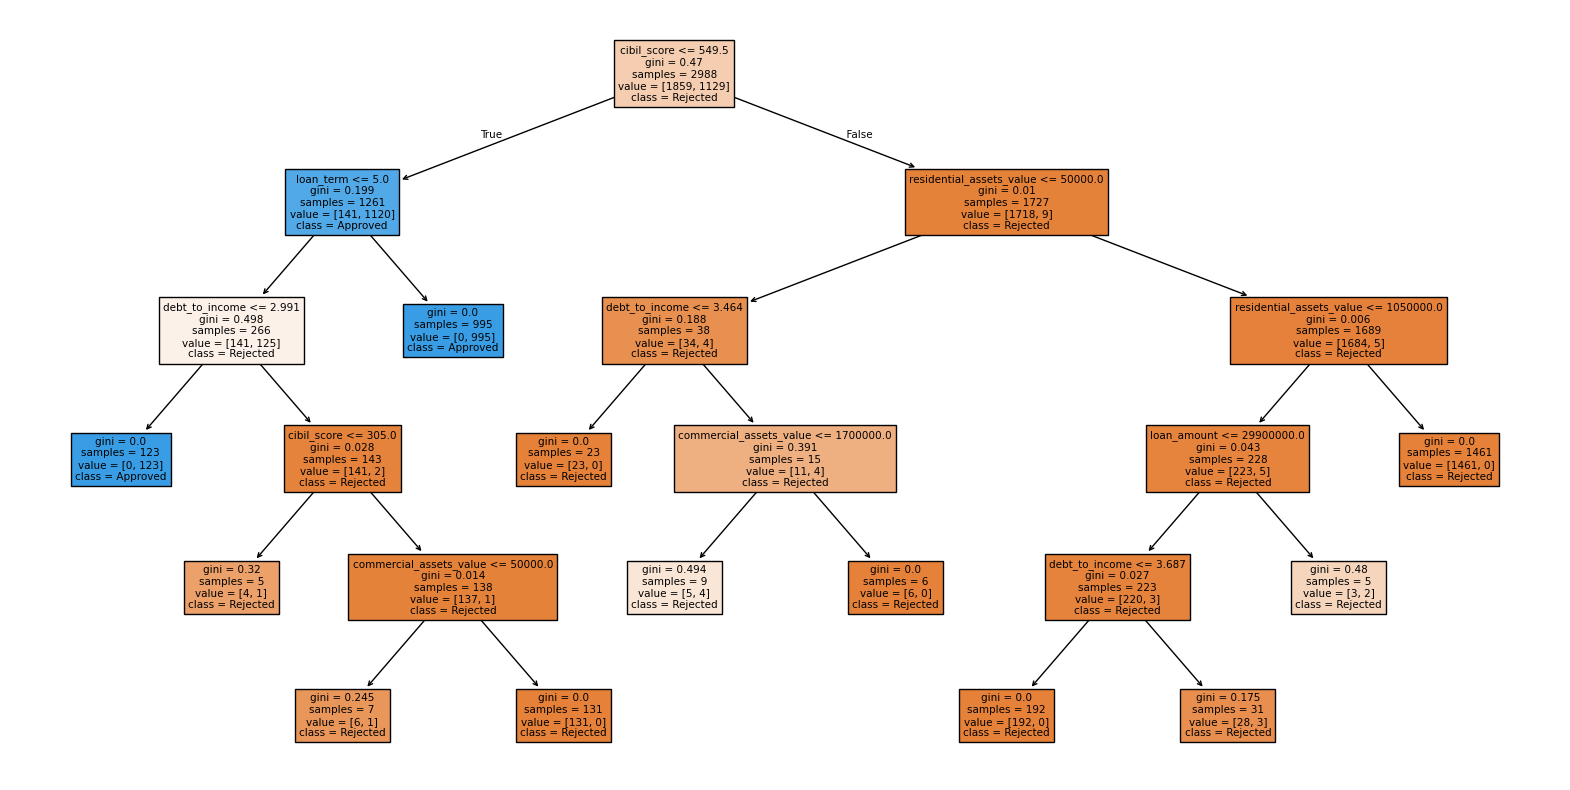

In [532]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(
    dt_tuned_manual,
    feature_names=X.columns,
    class_names=['Rejected','Approved'],
    filled=True
)
plt.show()

In [533]:
from sklearn.model_selection import GridSearchCV

param_grid_log = {
    'C': [0, 10,10.5,20],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'solver': ['liblinear', 'saga'],
    'l1_ratio': [0, 0.5, 1]
}

log = LogisticRegression(max_iter=1000)

grid_log = GridSearchCV(
    log,
    param_grid_log,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_log.fit(x_train, y_train)

print("Best Parameters:", grid_log.best_params_)
print("Best Score:", grid_log.best_score_)

Best Parameters: {'C': 10, 'l1_ratio': 0, 'penalty': 'l1', 'solver': 'liblinear'}
Best Score: 0.8928209164386967


c:\Users\TUF F16\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
135 fits failed out of a total of 360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\TUF F16\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\TUF F16\anaconda3\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\TUF F16\anaconda3\Lib\site-packages\sklearn\base.py", line 471, in _validate_p

In [534]:
model=grid_log.best_estimator_
evaluate_model(model,'grid_log.best_estimator_')


===== grid_log.best_estimator_ =====
Train Accuracy: 0.9220214190093708
Test Accuracy: 0.936768149882904
Precision: 0.929637526652452
Recall: 0.9008264462809917
F1 Score: 0.9150052465897167


In [535]:
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

dt = DecisionTreeClassifier(random_state=42)

grid_dt = GridSearchCV(
    dt,
    param_grid_dt,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_dt.fit(x_train, y_train)

print("Best DT Parameters:", grid_dt.best_params_)
print("Best DT Score:", grid_dt.best_score_)

Best DT Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best DT Score: 0.9942172289386967


In [536]:
model=grid_dt.best_estimator_
evaluate_model(model,'grid_dt.best_estimator_')


===== grid_dt.best_estimator_ =====
Train Accuracy: 0.9966532797858099
Test Accuracy: 0.9960967993754879
Precision: 0.997920997920998
Recall: 0.9917355371900827
F1 Score: 0.9948186528497409


In [537]:
values_data=pd.DataFrame(scores)
values_data

,model,train_accuracy,test_accuracy,precision,recall,f1_score
0,Logistic Regression (L2),0.814257,0.818891,0.815000,0.673554,0.737557
1,Logistic Regression (L1),0.922691,0.935988,0.933190,0.894628,0.913502
2,Decision Tree (Gini),1.000000,0.993755,0.991736,0.991736,0.991736
3,Decision Tree (Entropy),1.000000,0.990632,0.985597,0.989669,0.987629
4,Decision Tree (Manual Tuned),0.996319,0.996097,1.000000,0.989669,0.994808
5,grid_log.best_estimator_,0.922021,0.936768,0.929638,0.900826,0.915005
6,grid_dt.best_estimator_,0.996653,0.996097,0.997921,0.991736,0.994819
